<div style="background-color:#111827;
padding:25px;
border-left:8px solid #F59E0B;
border-radius:10px;
margin-bottom:20px;">

<h1 style="color:white;
font-size:34px;
margin:0;">
Series Temporales con Prophet de Meta
</h1>

<p style="color:#D1D5DB;
font-size:16px;
margin-top:10px;">
Pronostico de uso de pagos QR para los próximos 90 días
</p>

</div>

Este notebook presenta un estudio de pronóstico de series temporales utilizando Prophet, la librería desarrollada por Meta, con el objetivo de proyectar el volumen de pagos realizados mediante plataformas QR para un horizonte de 90 días.

El modelo se construye a partir de un dataset sintético/simulado, diseñado con fines exclusivamente educativos y de experimentación, permitiendo reproducir un escenario similar al que podría encontrarse en una entidad financiera o empresa del sector de medios de pago.

Además de la información histórica de transacciones, el modelo incorpora regresores externos que pueden influir en el comportamiento de la serie, entre ellos un calendario de feriados nacionales argentinos y un calendario personalizado de eventos comerciales, incluyendo fechas de alta actividad como Hot Sale, CyberMonday, Black Friday y otras jornadas especiales que suelen impactar en el volumen de operaciones.

<h2 style="
background-color:#111827;
color:white;
padding:14px;
border-radius:10px;
border-left:6px solid #F59E0B;
font-size:28px;
">
Índice
</h2>

<div style="
background-color:#1F2937;
padding:20px;
border-radius:10px;
margin-top:10px;
color:#E5E7EB;
font-size:16px;
line-height:2;
">

<a href="#0" style="color:#D1D5DB; text-decoration:none;">
1. Preparación y limpieza de los datos
</a>
<br>

<a href="#1" style="color:#D1D5DB; text-decoration:none;">
2. Análisis exploratorio de datos (EDA)
</a>
<br>

<a href="#2" style="color:#D1D5DB; text-decoration:none;">
3. Modelado y evaluación
</a>
<br>

<a href="#3" style="color:#D1D5DB; text-decoration:none;">
4. Conclusiones
</a>

</div>

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">01</span>
Preparación y limpieza de los datos
</div>
<a id="0"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

from prophet import Prophet
from great_tables import GT

import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # Borrar warnings

In [2]:
df = pd.read_csv("dataset_bancario_1100.csv") # Lectura del set de datos.

In [3]:
from great_tables import GT, style, loc
(GT(df.tail(7)).tab_style(style=style.fill(color="black"), locations=loc.column_labels()).tab_style(style=style.text(color="white", weight="bold"),
        locations=loc.column_labels()))

ds,pagos_qr,monto,comercios,clientes,inflación,dólar,promoción,feriado
2026-12-29,29747,249952144,12328,24913,6.6,1227.0,0,0
2026-12-30,32038,275481444,12337,24542,7.1,1251.0,1,0
2026-12-31,29736,256643370,12617,24587,6.5,1239.0,0,0
2027-01-01,32796,288172209,12560,24935,6.6,1255.0,1,0
2027-01-02,30371,257676586,12561,24602,4.9,1250.0,0,1
2027-01-03,35158,305220787,12387,25005,7.2,1240.0,1,1
2027-01-04,29676,254927380,12350,24703,6.8,1257.0,0,0


In [4]:
df['ds'] = pd.to_datetime(df['ds']) # Convierto la columna ds al tipo de dato fecha y hora (datetime) de Pandas.

In [5]:
# Validación de integridad temporal (obligatoria antes de Prophet)
assert df['ds'].is_unique, "Hay fechas duplicadas en 'ds'"
rango_completo = pd.date_range(df['ds'].min(), df['ds'].max(), freq='D')
faltantes = rango_completo.difference(df['ds'])
print(f"Días faltantes en la serie: {len(faltantes)}")
if len(faltantes) > 0:
    print(faltantes[:10])

Días faltantes en la serie: 0


In [6]:
(df.describe().T.style.background_gradient(cmap='gist_gray').format('{:.2f}'))

,count,mean,std,min,25%,50%,75%,max
pagos_qr,1100.00,26147.76,3868.62,17805.00,23304.75,26090.50,28991.00,36097.00
monto,1100.00,224720554.09,34162248.08,151165768.00,200324263.25,224139013.50,249109475.25,313886956.00
comercios,1100.00,10237.15,1357.14,7434.00,9146.00,10205.50,11364.50,13021.00
clientes,1100.00,20489.52,2691.25,15127.00,18219.00,20428.50,22720.25,25798.00
inflación,1100.00,12.53,3.52,4.60,9.50,12.40,15.60,19.70
dólar,1100.00,1035.58,124.59,777.00,927.00,1038.00,1143.00,1278.00
promoción,1100.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
feriado,1100.00,0.31,0.46,0.00,0.00,0.00,1.00,1.00


In [7]:
df.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ds         1100 non-null   datetime64[ns]
 1   pagos_qr   1100 non-null   int64         
 2   monto      1100 non-null   int64         
 3   comercios  1100 non-null   int64         
 4   clientes   1100 non-null   int64         
 5   inflación  1100 non-null   float64       
 6   dólar      1100 non-null   float64       
 7   promoción  1100 non-null   int64         
 8   feriado    1100 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6)

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">02</span>
Análisis exploratorio de datos (EDA)
</div>
<a id="1"></a>

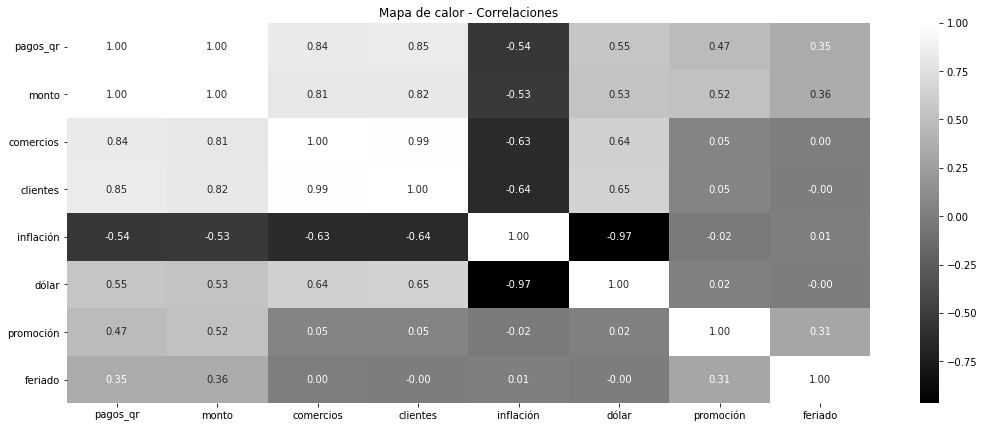

In [8]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(18, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='gist_gray')
plt.title('Mapa de calor - Correlaciones')
plt.show()

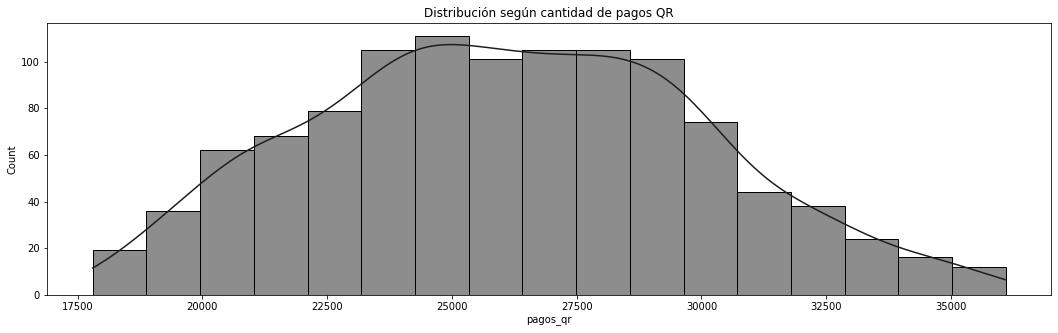

In [9]:
plt.figure(figsize=(18,5))
sns.histplot(df['pagos_qr'],kde=True, color="#1d1d1d")
plt.title('Distribución según cantidad de pagos QR')

plt.show()

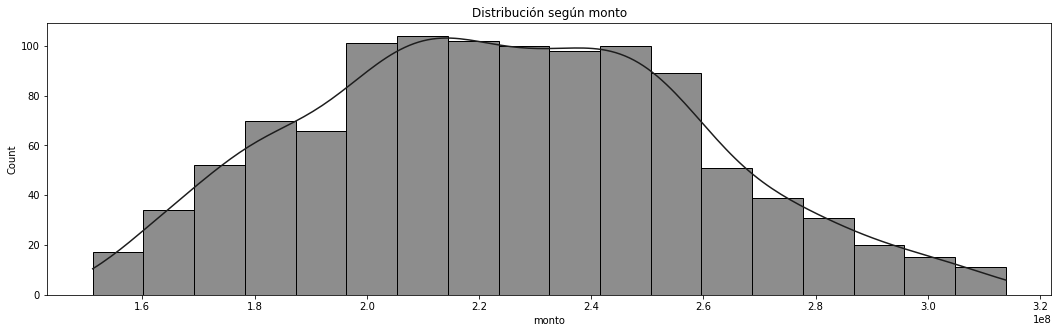

In [10]:
plt.figure(figsize=(18,5))
sns.histplot(df['monto'],kde=True, color="#1d1d1d")
plt.title('Distribución según monto')
plt.show()

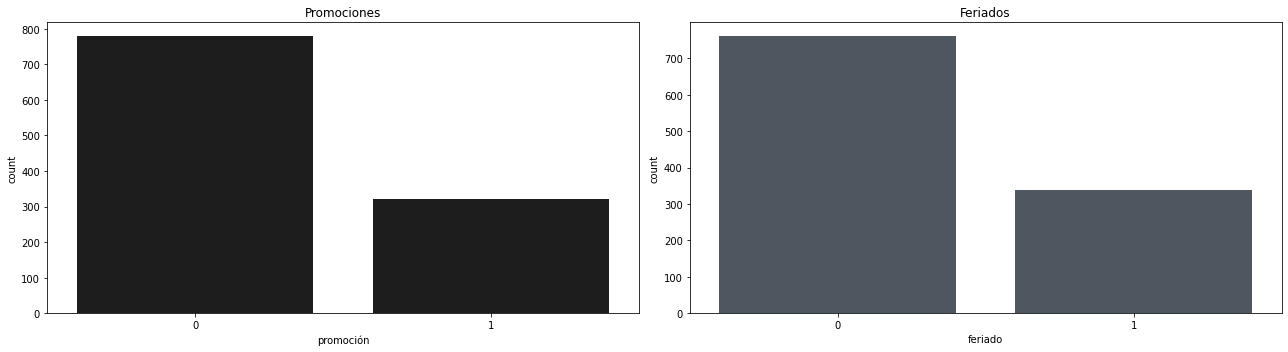

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(18,5))

sns.countplot(data=df, x="promoción", color="#1d1d1d", ax=ax[0])
ax[0].set_title("Promociones")

sns.countplot(data=df, x="feriado", color="#4B5563", ax=ax[1])
ax[1].set_title("Feriados")

plt.tight_layout()
plt.show()

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">03</span>
Modelado y evaluación
</div>
<a id="2"></a>

### ▣ Prophet

In [12]:
# Copio el DF y renombro columnas para poder utilizar Prophet (requiere 2 columnas, una con nombre "ds" y otra con nombre "y").
df_prophet = df.copy()
df_prophet = df_prophet.rename(columns={'pagos_qr': 'y'})

In [13]:
eventos_especiales_md = {
    #'01-01': 1,   # Año Nuevo (Excluidos por estar en la libreria de prophet)
    '02-14': 2,   # San Valentín
    '03-08': 2,   # Día de la Mujer
    #'05-01': 1,   # Día del Trabajador (Excluidos por estar en la libreria de prophet)
    '05-20': 3,   # Hot Sale
    #'07-09': 1,   # Día de la Independencia (Excluidos por estar en la libreria de prophet)
    '09-21': 1,   # Día de la Primavera
    '10-15': 3,   # CyberMonday
    '11-29': 3,   # Black Friday
    '12-02': 3,   # CyberMonday
    #'12-25': 3,   # Navidad (Excluidos por estar en la libreria de prophet)
    '12-31': 2,   # Fin de Año
}
# arriba esta asi, (fecha, intensidad) - donde intensidad: 1=normal, 2=fuerte, 3=extrafuerte

# Función para asignar promociones
def asignar_promocion(fecha):
    mes_dia = fecha.strftime('%m-%d')
    if mes_dia in eventos_especiales_md:
        return eventos_especiales_md[mes_dia]
    if fecha.dayofweek in [0, 1, 2]:
        return 1
    return 0

In [14]:
# Vuelvo a calcular historico con la misma escala (1,2,3) que usare en future.
df_prophet['promoción'] = df_prophet['ds'].apply(asignar_promocion)

In [15]:
REGRESORES = ['promoción', 'feriado'] # Aca se le dice que existen dos variables adicionales que afectan a Y, Prophet intentará aprender cuanto cambia "y" cuando estas variables valen 1

model = Prophet(
    yearly_seasonality=True, # especifico que busque patrones que se repiten cada año (ejemplo: navidad, vacaciones, etc).
    weekly_seasonality=True, # especifico que busque patrones semanales. Que dias se mueven mas.
    daily_seasonality=False # No lo uso, porque el dataframe no tiene valores en horas y minutos que lo justifique.
)
for reg in REGRESORES:
    model.add_regressor(reg) # Codigo para agregar los regresores, prophet debe usarlas en el entrenamiento.

model.fit(df_prophet) # Entrenar el modelo.

18:30:40 - cmdstanpy - INFO - Chain [1] start processing
18:30:40 - cmdstanpy - INFO - Chain [1] done processing


<div class="alert alert-warning">Con el objetivo de capturar con precisión las variaciones en la demanda, se diseñó un calendario integrado de promociones que combina dos tipos de eventos comerciales:

-Eventos Estacionales (Holidays específicos): Fechas comerciales clave con alto impacto en la facturación.  
-Efectos Recurrentes Semanales: Promociones fijas implementadas de lunes a miércoles para contrarrestar los días de históricamente baja actividad comercial.

Esta diferenciación me permitirá alimentar el modelo Prophet mediante componentes externos personalizados, logrando aislar el impacto de la estrategia comercial del ruido natural de la serie temporal.</div>

In [16]:
future = model.make_future_dataframe(periods=90) # Crea un DF con fechas futuras para poder generar predicciones.
future['promoción'] = future['ds'].apply(asignar_promocion) # Asignar para el futuro

In [17]:
# feriado futuro: se calcula con la librería 'holidays' (Argentina), no hay que asumir nada. No se superpone con lo anterior puesto que aca es
# binario (0/1) y en el anterior se le da un orden (1,2,3) de importancia.
anios = range(future['ds'].dt.year.min(), future['ds'].dt.year.max() + 1)
ar_holidays = holidays.Argentina(years=anios)
future['feriado'] = future['ds'].dt.date.astype(str).isin([str(d) for d in ar_holidays]).astype(int)

In [18]:
forecast = model.predict(future)

In [19]:
print("           ----- PREDICCIONES COMPLETAS: -----")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(20))

# Ver solo las predicciones futuras (últimos 90 días)
future_predictions = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(90)
print("\n   ----- PREDICCIONES PARA LOS PRÓXIMOS 90 DÍAS: -----")
print(future_predictions.head(10))
print(f"...")
print(future_predictions.tail(10))

print("\n   ----- ESTADÍSTICAS DE PREDICCIONES: -----")
print(future_predictions[['yhat', 'yhat_lower', 'yhat_upper']].describe())

           ----- PREDICCIONES COMPLETAS: -----
             ds          yhat    yhat_lower    yhat_upper
1170 2027-03-16  29868.574607  27435.824202  32129.543247
1171 2027-03-17  30115.749721  27770.418377  32354.053775
1172 2027-03-18  29955.733530  27838.762579  32176.600112
1173 2027-03-19  29711.759589  27470.808917  32079.037440
1174 2027-03-20  30483.134120  28030.464163  32902.296012
1175 2027-03-21  30564.696042  28233.835207  32911.526687
1176 2027-03-22  29841.565796  27629.139077  32272.251987
1177 2027-03-23  29781.451947  27481.876835  32266.157283
1178 2027-03-24  32355.871721  29951.812608  34870.469565
1179 2027-03-25  32180.793210  29722.375093  34510.150685
1180 2027-03-26  31927.541667  29595.734071  34301.573547
1181 2027-03-27  30348.086987  28108.148315  32926.642798
1182 2027-03-28  30432.668567  27940.555049  32830.658752
1183 2027-03-29  29718.731267  27155.323788  32204.668779
1184 2027-03-30  29673.771165  27283.682760  32217.995283
1185 2027-03-31  29921.29

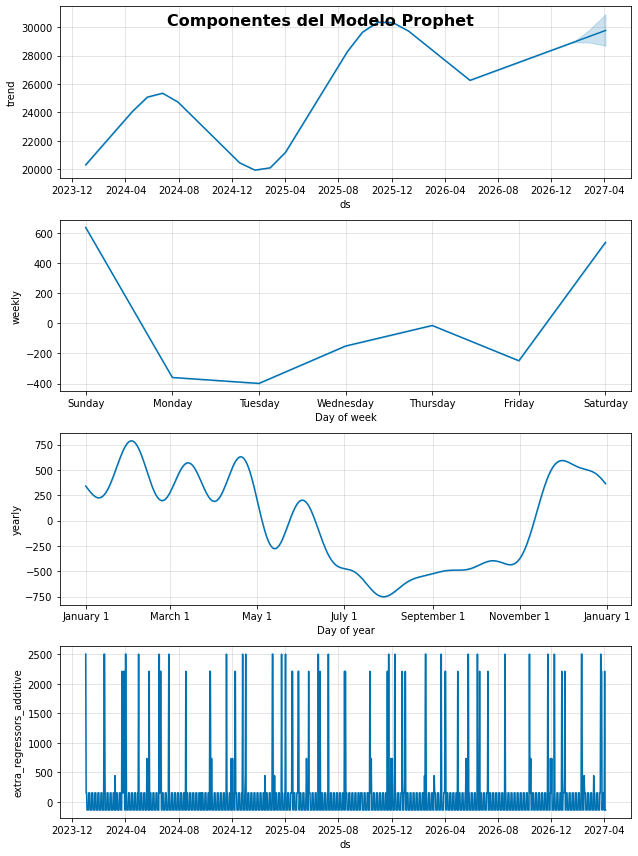

In [20]:
# Graficar los componentes del modelo
fig2 = model.plot_components(forecast)
plt.suptitle('Componentes del Modelo Prophet', fontsize=16, fontweight='bold')
plt.show()

<div class="alert alert-warning">

1. **Tendencia (trend):** Muestra la dirección general de los datos a largo plazo, quitando el ruido de los días o los meses. En este caso muestra una tendencia general al alza desde finales de 2023 hasta principios de 2027. No es una línea recta, tiene fluctuaciones y luego se estabiliza subiendo. Al final de la linea (en abril 2027) se ven los intervalos de incertidumbre de la predicción a futuro.  
2. **Estacionalidad Semanal (weekly):** Muestra el comportamiento o patrón que se repite cada semana según el día. El grafico dice que los fines de semana (domingo y sábado) tienen un impacto altísimo y positivo en la métrica, en cambio durante los días de semana (lunes a viernes), la actividad cae drásticamente y se mantiene en negativo respecto a la media.    
3. **Estacionalidad Anual (yearly):** Muestra cómo varían los datos a lo largo de los meses de un año completo (de enero a enero). Hay una estacionalidad anual muy marcada. El pico más alto ocurre en los primeros meses del año y a partir de mayo, empieza a caer en hasta tocar fondo aproximadamente en agosto, para luego volver a recuperarse con fuerza hacia el fin de año.    
4. **Regresores Extra Aditivos (extra_regressors_additive):** Estos son eventos o variables externas que fueron agregados al modelo (feriados, días de promociones especiales, eventos tipo Black Friday, etc). Esos picos o líneas verticales muestran momentos exactos en el tiempo donde ocurrió un evento especial que le sumó un valor fijo (cercano a 2.500) a la predicción general.</div>

In [21]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING) # oculta todos los mensajes INFO y DEBUG de libreria (cmdstanpy)

from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

df_cv = cross_validation(model, initial='730 days', period='90 days', horizon='90 days') # Validacion cruzada para series temporales.
df_metrics = performance_metrics(df_cv)

df_metrics[['horizon', 'mae', 'rmse', 'mape']].head(10)

  0%|          | 0/4 [00:00<?, ?it/s]

,horizon,mae,rmse,mape
0,9 days,1606.956152,2116.824711,0.055867
1,10 days,1621.322540,2039.086048,0.055800
2,11 days,1704.011514,2076.104260,0.058738
3,12 days,1675.698266,2032.571774,0.058175
4,13 days,1891.267808,2259.163004,0.066022
5,14 days,1910.617405,2342.363836,0.066513
6,15 days,2020.165209,2563.332771,0.069350
7,16 days,2140.595654,2650.693870,0.073306
8,17 days,2257.461630,2719.690576,0.077451
9,18 days,2394.545832,2821.401537,0.082507


<div class="alert alert-warning">Esta validación simula cómo habría funcionado haciendo pronósticos desde distintos momentos del pasado. Esto proporciona una estimación mucho más realista de su capacidad para predecir datos futuros. En general el modelo es bueno puesto que el MAPE no crece mucho, no hay saltos bruscos osea que tiene un comportamiento estable a medida que crece el horizonte temporal.</div>

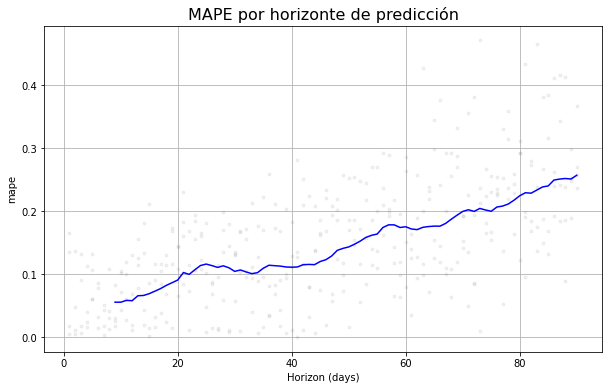

In [22]:
plot_cross_validation_metric(df_cv, metric='mape')

plt.title("MAPE por horizonte de predicción", fontsize=16)
plt.show()

<div class="alert alert-warning">   
    
-  El **Eje X (Horizontal)** es el horizonte de predicción, cuanto mas a la derecha más lejos está intentando predecir el modelo. 
    
- El **Eje Y** es el MAPE = Error porcentual promedio.

- La línea azul resume la tendencia general de esos errores donde es completamente esperable que aumente porque mientras más lejos predice Prophet más incertidumbre existe. La pendiente de la línea azul no es tan grande es mas plana osea el modelo mantiene su calidad al aumentar el horizonte.</div>

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">04</span>
Conclusiones
</div>
<a id="3"></a>

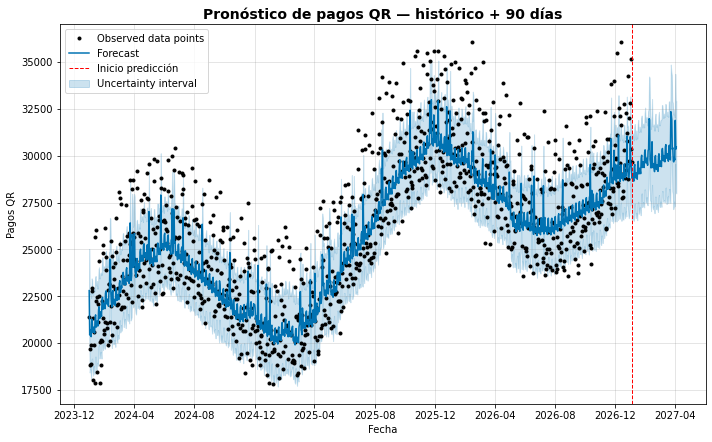

In [23]:
fig1 = model.plot(forecast)

ax = fig1.gca()
ax.axvline(x=df_prophet['ds'].max(), color='red', linestyle='--', 
           linewidth=1, label='Inicio predicción')
ax.set_title('Pronóstico de pagos QR — histórico + 90 días', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Pagos QR')
ax.legend()
plt.show()

<div class="alert alert-warning">

- **Puntos negros (y):** Son los datos históricos reales (las observaciones reales con las que se entrenó el modelo). Representan la dispersión y la volatilidad real del negocio o proceso. Hay días con picos muy altos que se escapan del promedio reflejando el ruido natural de los datos.

- **La línea azul fuerte (yhat):** Es la predicción/ajuste del modelo. En la parte donde se cruza con los puntos negros muestra cómo aprendió el modelo a imitar el pasado (su nivel de ajuste). Los picos hacia arriba que tiene la línea azul de forma regular corresponden al efecto de los regresores extra y la estacionalidad de los fines de semana. En la parte de predicciones (a la derecha de la linea puntuada roja) los puntos negros desaparecen. porque ahí la línea azul pasa a ser puramente el pronóstico (forecast) a futuro.

- **La franja sombreada azul claro:** Es el intervalo de incertidumbre (por defecto suele ser del 80% o 95%). Es el margen de error esperado, el modelo dice por ejemplo que no sabe el numero exacto del día de mañana, pero hay un alto nivel de confianza en que el valor real va a caer dentro de esta banda sombreada.

En este caso el modelo logra capturar muy bien los ciclos de estos datos. La línea azul copia la gran curva de subidas y bajadas anuales y se mantiene en el centro de la masa de puntos negros. Hacia el futuro (2027) proyecta que la variable va a quebrar la barrera de los 30.000 siguiendo la tendencia alcista de largo plazo.</div>

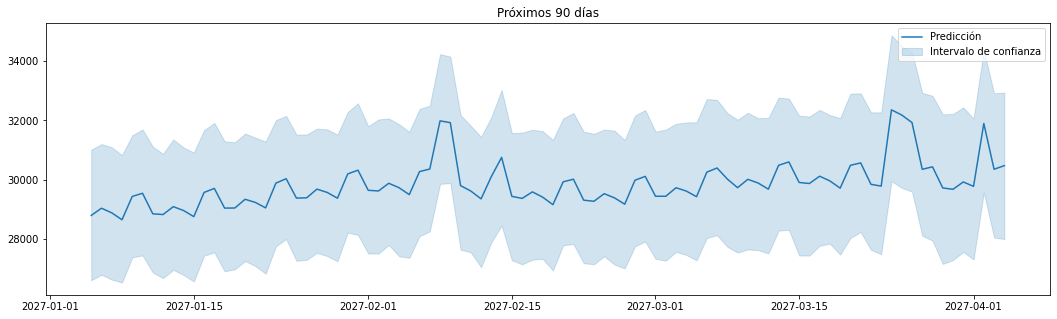

In [24]:
fig, ax = plt.subplots(figsize=(18,5))
fc_future = forecast.tail(90)
ax.plot(fc_future['ds'], fc_future['yhat'], label='Predicción', color='C0')
ax.fill_between(fc_future['ds'], fc_future['yhat_lower'], fc_future['yhat_upper'],
                 alpha=0.2, color='C0', label='Intervalo de confianza')
ax.set_title('Próximos 90 días')
ax.legend()
plt.show()

<div style="
    margin-top:40px;
    padding:16px;
    border-radius:12px;
    background:linear-gradient(90deg,#0B1220,#111827);
    border-left:4px solid #F59E0B;
    color:#E5E7EB;
    font-size:13px;
    line-height:1.6;
">
<div style="font-weight:600; font-size:14px;">
Néstor Díaz
</div>

<div style="color:#94A3B8;">
Contador Público · Data Analyst · Machine Learning
</div>

<div style="margin-top:8px; color:#F59E0B;">
Proyecto: Pronostico de uso de pagos QR para los próximos 90 días.
</div>
</div>